In [1]:
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([transforms.ToTensor(), 
                                #transforms.Normalize((0.1307,), (0.3081,)),
                                ]) #flatten serve per convertire le immagini in vettori di 784 unità 

mnist_train = MNIST(root='mnist',train=True, download=True, transform=transform)
mnist_test = MNIST(root='mnist',train=False, download=True, transform=transform)


mnist_train_loader = DataLoader(mnist_train, batch_size=512, num_workers=2, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=512, num_workers=2)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from pytorch_lightning.loggers import TensorBoardLogger
from torchvision.utils import make_grid
from classes import *

In [3]:
#Load of the models
encoder = torch.load('vit2_encoder.pth')
decoder = torch.load('decoder2.pth')

device = torch.device('mps')

In [4]:
#Data division 
for i in range(512):
        img = mnist_test[i][0].unsqueeze(0)
        img = img.to(device)
        #encode and add to the vector
        output = encoder(img)
        if i == 0:
            loss_img = img
            encoded_imgs = output
        else:
            loss_img = torch.cat((loss_img, img), 0)
            encoded_imgs = torch.cat((encoded_imgs, output), 0) 

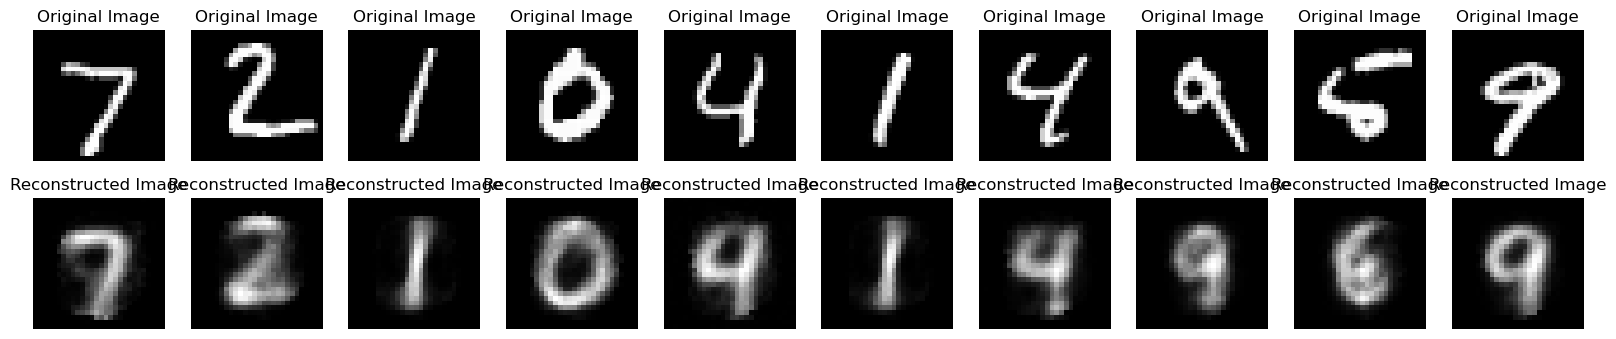

In [5]:
fig, axs = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
        img = encoded_imgs[i]
        loss_imgs = loss_img[i]
        img = img.to(device)

        output = decoder(img)

        axs[0, i].imshow(loss_imgs.cpu().numpy().squeeze(), cmap='gray')
        axs[0, i].axis('off')
        axs[0, i].set_title('Original Image')

        axs[1, i].imshow(output.cpu().detach().numpy().squeeze(), cmap='gray')
        axs[1, i].axis('off')
        axs[1, i].set_title('Reconstructed Image')

plt.show()